# ML Final Lab Project — Bank Marketing (Term-Deposit Subscription)
**Master in Data Science — Machine Learning (UPC · FIB), 2026**

**Team members:** Pablo Rodríguez, Adrián Segura

**Task.** Binary classification: predict whether a client subscribes to a term deposit (`y`). The dataset is real (Portuguese bank tele-marketing, Moro et al. 2014), with mixed numeric/categorical features and strong class imbalance (~17.5% positives, a ~4.7:1 ratio).

**What this notebook delivers.** A single coherent pipeline covering the five required phases (unsupervised analysis, regularised linear models, kernel methods, ensembles, and model selection/validation), plus EDA, preprocessing, feature extraction/selection, and interpretation.

---


## Key methodological decisions (read first)

Brief summary of the choices justified in detail in the written report; each is revisited where applied.

1. **`duration` dropped (leakage).** It is only known *after* the call, so it cannot be used for pre-call prediction; the with/without gap is quantified in the EDA.
2. **`'unknown'` kept as its own category** (there are no `NaN`s). In `poutcome` (76%) and `contact` (24%) it is structural, not random missingness.
3. **`pdays = -1` is a sentinel** ("never previously contacted", 74%): we engineer a binary `prev_contacted` flag and clip `pdays`.
4. **Imbalance** (~17.5% positives): `class_weight='balanced'` where supported, plus threshold-independent metrics (AUPR, ROC-AUC) and decision-threshold tuning for the boosting models.
5. **Leakage-free validation:** all preprocessing lives inside the `Pipeline` (re-fit per fold); hyper-parameters are tuned on the training set only and the test set is used once. Models are compared with **nested CV** and ranked by **AUPR** — accuracy is misleading here (a majority classifier already scores 82.5%).

---


## 0. Setup, configuration & imports

In [1]:
# ---- Reproducibility & runtime configuration ----
SEED = 42
DATA_PATH = 'Bank_Marketing_Dataset.csv'

DROP_DURATION = True      # decision #1: exclude leaky feature from predictive models
TEST_SIZE = 0.2

# Phase I clustering
K_MAX = 10
SIL_SAMPLE = 5000         # silhouette on a sample for speed

# Phase II logistic path
CP_PATH_POINTS = 15

# Phase III SVM
SVM_SUBSAMPLE = 8000      # kernel SVM is ~O(n^2); subsample for tractability

# Phase IV ensembles (final, deployed models)
RF_N_EST = 300
GB_N_EST = 200
ADA_N_EST = 200

# Phase IV/V permutation importance
PERM_REPEATS = 5

# Phase V nested CV (lighter estimators keep the unbiased estimate tractable)
OUTER_SPLITS = 5
INNER_SPLITS = 3
RF_N_EST_NESTED = 200
GB_N_EST_NESTED = 100
print('Config loaded (FULL).')

Config loaded (FULL).


In [2]:
# Core
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing / pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.utils import resample

# Model selection
from sklearn.model_selection import (train_test_split, cross_val_score, cross_validate,
                                     cross_val_predict, GridSearchCV, StratifiedKFold)

# Unsupervised
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Models
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, lasso_path
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier)
from sklearn.dummy import DummyClassifier

# Metrics / inspection
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             roc_auc_score, average_precision_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, precision_recall_curve)
from sklearn.inspection import permutation_importance

from scipy.stats import pointbiserialr, chi2_contingency, ttest_rel, wilcoxon

np.random.seed(SEED)
sns.set_style('whitegrid')
print('Imports OK. scikit-learn pipeline-based, leakage-free CV enabled.')

Imports OK. scikit-learn pipeline-based, leakage-free CV enabled.


---
## 1. Exploratory Data Analysis (EDA)

### 1.1 Load data

In [3]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,management,single,tertiary,no,444,yes,no,unknown,28,may,177,17,-1,0,unknown,no
1,37,technician,married,secondary,no,787,yes,no,cellular,1,feb,106,1,-1,0,unknown,no
2,71,retired,married,secondary,no,2715,no,no,telephone,13,aug,683,4,-1,0,unknown,no
3,84,retired,divorced,primary,no,12088,no,no,telephone,12,dec,130,3,-1,0,unknown,yes
4,55,retired,married,unknown,no,161,no,no,cellular,8,jul,98,1,-1,0,unknown,no


### 1.2 Types, missing values, descriptive statistics
Note: pandas reports **0 NaNs** — missing information is stored as the string `'unknown'`, which we inspect explicitly in 1.7.

In [4]:
print('=== dtypes ===')
print(df.dtypes)
print('\n=== NaN per column ===')
print(df.isnull().sum().to_string())
df.describe(include='all').T

=== dtypes ===
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

=== NaN per column ===
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.909425,11.380169,18.0,31.0,40.0,49.0,95.0
job,45211,12,technician,10404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,20415,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,21598,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,42607,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1500.773086,2852.584799,-4290.0,130.0,593.0,1642.5,33723.0
housing,45211,2,yes,26930,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,40459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,30153,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.841654,8.001934,1.0,9.0,16.0,21.0,31.0


### 1.3 Target variable — class imbalance

y
no     37281
yes     7930

Positive rate: 0.1754  |  Imbalance ratio: 4.70 : 1
A trivial majority-class baseline would score Accuracy = 0.8246


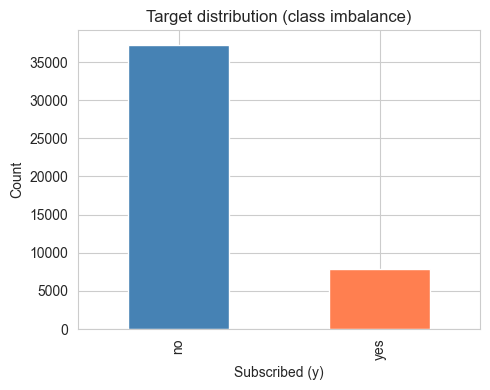

In [5]:
counts = df['y'].value_counts()
pos_rate = (df['y'] == 'yes').mean()
print(counts.to_string())
print(f'\nPositive rate: {pos_rate:.4f}  |  Imbalance ratio: {counts["no"]/counts["yes"]:.2f} : 1')
print(f'A trivial majority-class baseline would score Accuracy = {1-pos_rate:.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('Target distribution (class imbalance)')
ax.set_xlabel('Subscribed (y)'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

### 1.4 Numerical feature distributions

Numerical columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


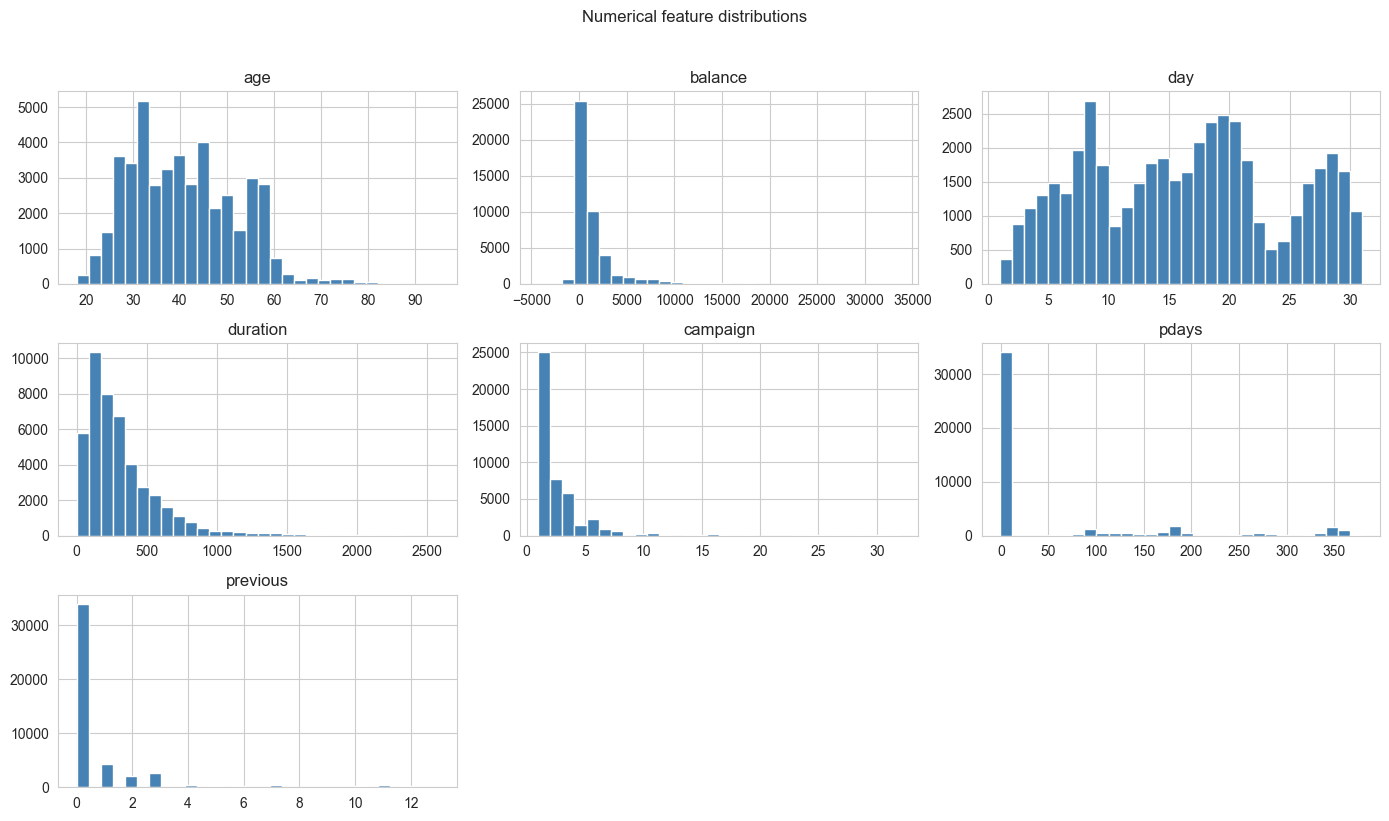

In [6]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print('Numerical columns:', num_cols)
df[num_cols].hist(figsize=(14, 8), bins=30, color='steelblue', edgecolor='white')
plt.suptitle('Numerical feature distributions', y=1.02)
plt.tight_layout(); plt.show()

### 1.5 Categorical feature counts

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


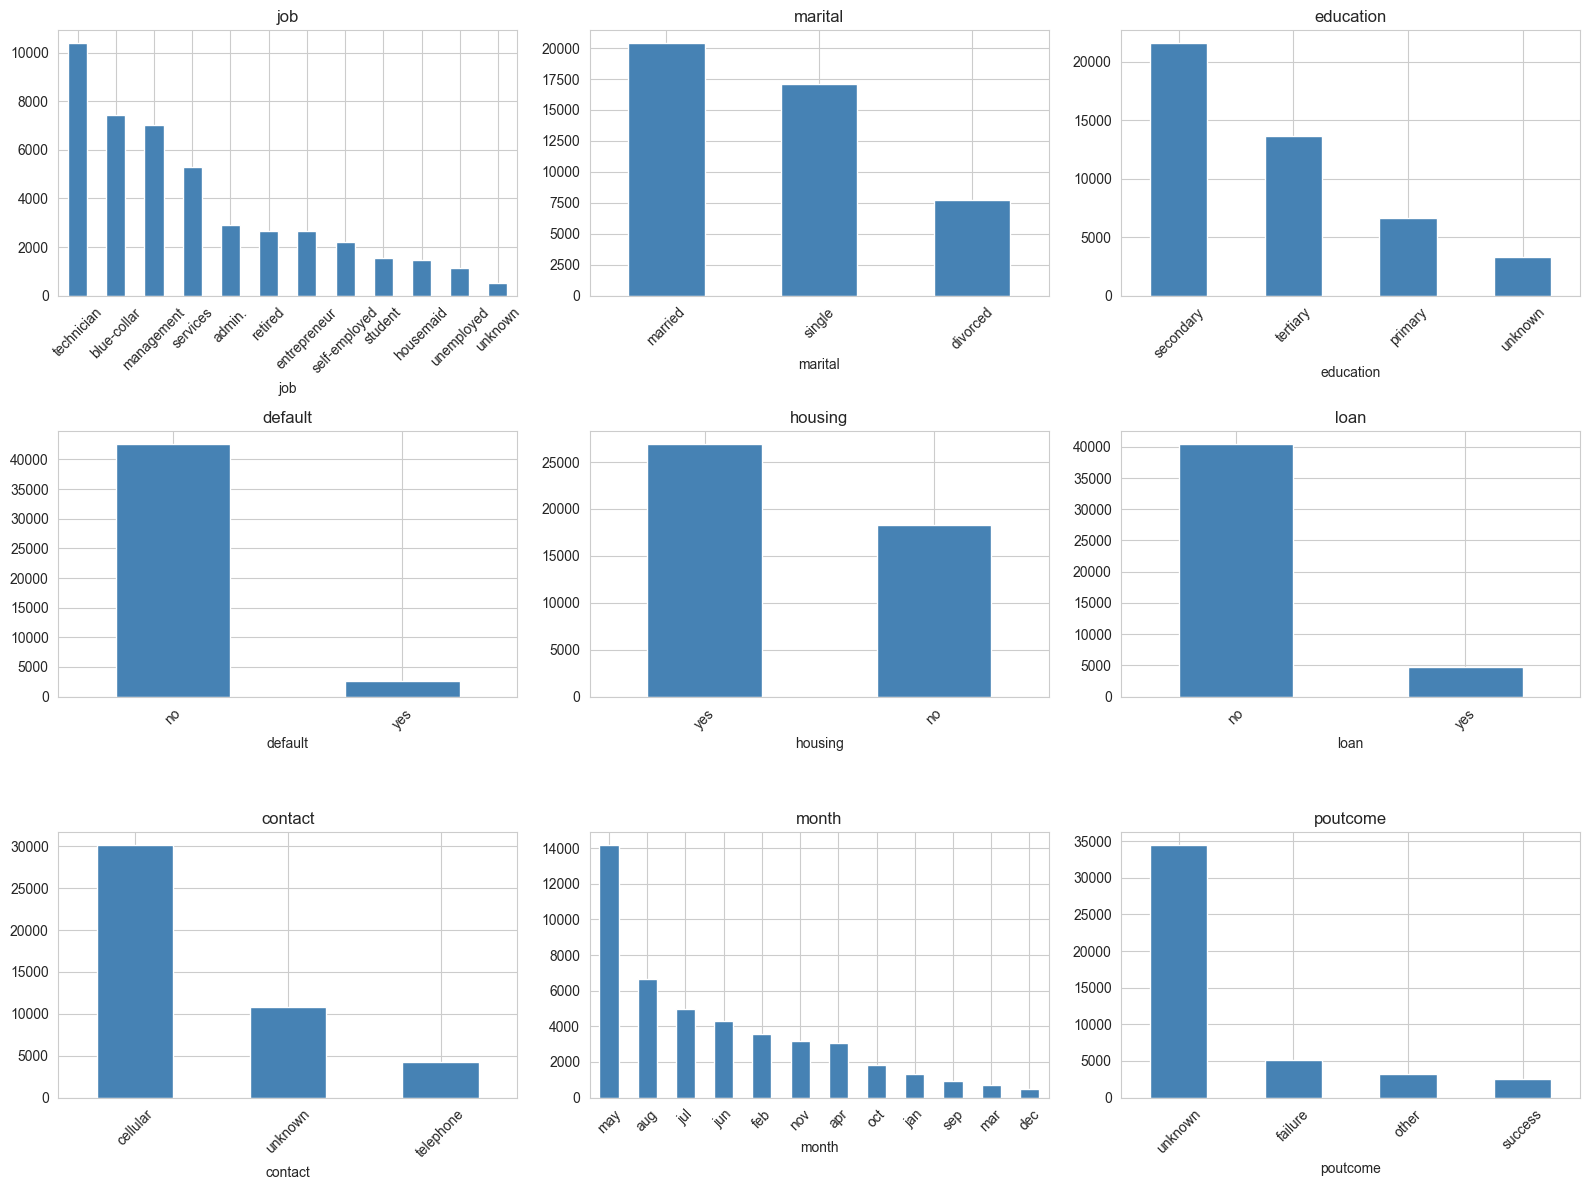

In [7]:
cat_cols = df.select_dtypes(include='object').columns.drop('y').tolist()
print('Categorical columns:', cat_cols)
fig, axes = plt.subplots(3, 3, figsize=(16, 12)); axes = axes.flatten()
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(col); axes[i].tick_params(axis='x', rotation=45)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout(); plt.show()

### 1.6 Subscription rate by category (where the signal is)
Marginal counts are not enough; what matters for the task is how the **positive rate** varies across levels. `poutcome='success'`, being reached on `cellular`, and certain months stand out — these become the strongest features later.

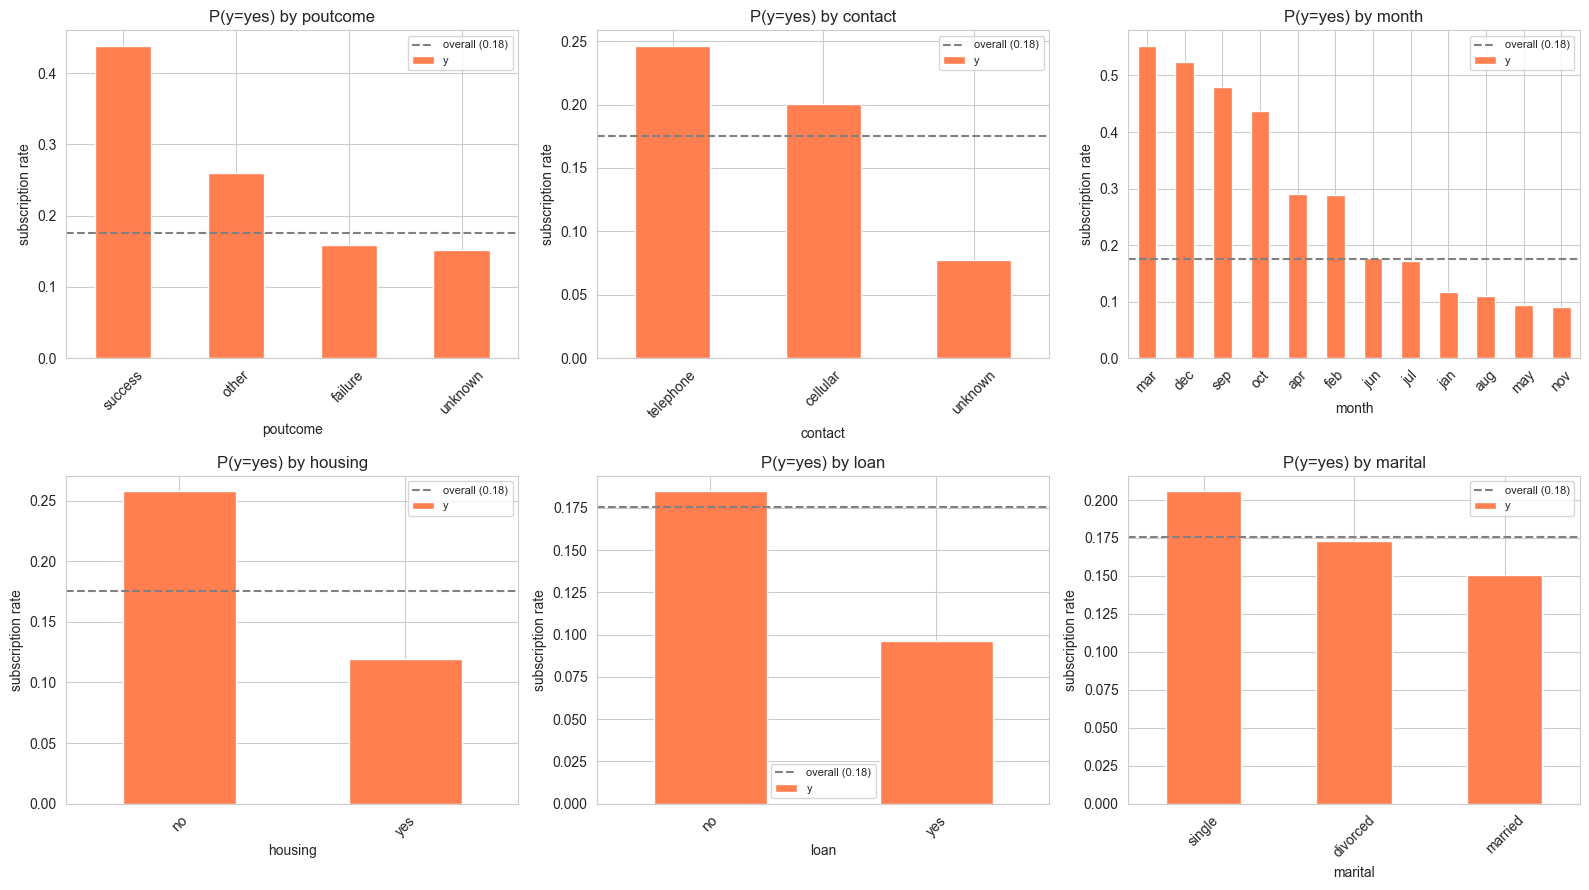

In [8]:
key_cats = ['poutcome', 'contact', 'month', 'housing', 'loan', 'marital']
fig, axes = plt.subplots(2, 3, figsize=(16, 9)); axes = axes.flatten()
base = (df['y'] == 'yes').mean()
for i, col in enumerate(key_cats):
    rate = df.groupby(col)['y'].apply(lambda s: (s == 'yes').mean()).sort_values(ascending=False)
    rate.plot(kind='bar', ax=axes[i], color='coral')
    axes[i].axhline(base, ls='--', color='gray', label=f'overall ({base:.2f})')
    axes[i].set_title(f'P(y=yes) by {col}'); axes[i].set_ylabel('subscription rate')
    axes[i].tick_params(axis='x', rotation=45); axes[i].legend(fontsize=8)
plt.tight_layout(); plt.show()

### 1.7 Quantifying association with the target
Point-biserial correlation for numeric features and **Cramér's V** for categoricals give an early, model-free ranking of predictive strength.

In [9]:
y_bin = (df['y'] == 'yes').astype(int)

print('=== Numeric vs y (point-biserial) ===')
pb = {}
for col in num_cols:
    r, p = pointbiserialr(df[col], y_bin)
    pb[col] = r
    print(f'{col:12s} | r = {r:+.3f} | p = {p:.1e}')

def cramers_v(x, y):
    ct = pd.crosstab(x, y); chi2 = chi2_contingency(ct)[0]
    n = ct.values.sum(); return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print("\n=== Categorical vs y (Cramer's V) ===")
cv = {col: cramers_v(df[col], df['y']) for col in cat_cols}
for col, v in sorted(cv.items(), key=lambda kv: -kv[1]):
    print(f'{col:12s} | V = {v:.3f}')

=== Numeric vs y (point-biserial) ===
age          | r = +0.034 | p = 5.1e-13
balance      | r = +0.069 | p = 2.2e-48
day          | r = -0.115 | p = 1.3e-132
duration     | r = +0.372 | p = 0.0e+00
campaign     | r = -0.098 | p = 4.7e-96
pdays        | r = +0.066 | p = 2.8e-45
previous     | r = +0.089 | p = 1.9e-80

=== Categorical vs y (Cramer's V) ===
month        | V = 0.305
job          | V = 0.201
poutcome     | V = 0.181
housing      | V = 0.178
contact      | V = 0.149
loan         | V = 0.071
marital      | V = 0.065
education    | V = 0.060
default      | V = 0.055


### 1.8 Numeric correlation heatmap

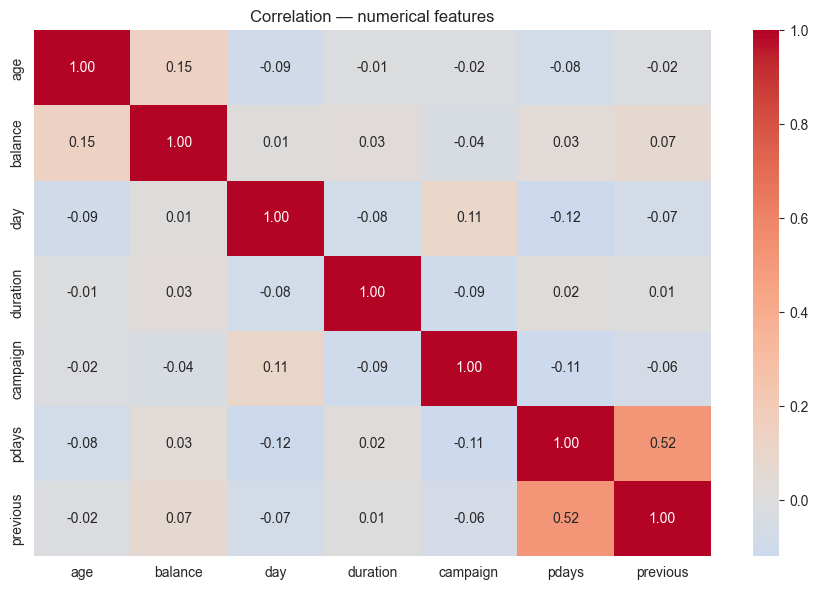

In [10]:
plt.figure(figsize=(9, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation — numerical features'); plt.tight_layout(); plt.show()

### 1.9 `'unknown'` levels and the `pdays` / `previous` structure

In [11]:
print("=== 'unknown' share per categorical ===")
for col in cat_cols:
    n = (df[col] == 'unknown').sum()
    if n: print(f'{col:12s} | unknown: {n:6d} ({100*n/len(df):5.1f}%)')

print('\n=== pdays / previous structure ===')
share = (df['pdays'] == -1).mean()
print(f'pdays == -1 (never contacted before): {(df["pdays"]==-1).sum()} ({100*share:.1f}%)')
print(f'previous == 0:                        {(df["previous"]==0).sum()}')
print('-> pdays=-1 is a sentinel; we will turn it into a binary `prev_contacted` flag.')

=== 'unknown' share per categorical ===
job          | unknown:    513 (  1.1%)
education    | unknown:   3315 (  7.3%)
contact      | unknown:  10833 ( 24.0%)
poutcome     | unknown:  34464 ( 76.2%)

=== pdays / previous structure ===
pdays == -1 (never contacted before): 33298 (73.7%)
previous == 0:                        33965
-> pdays=-1 is a sentinel; we will turn it into a binary `prev_contacted` flag.


### 1.10 The `duration` leakage — measured
`duration` separates the classes strongly, *but it is unknown before the call is placed*. We quantify how much it inflates performance so we can justify excluding it. The realistic models below use the feature set **without** `duration`.

In [13]:
print('Mean call duration by outcome (seconds):')
print(df.groupby('y')['duration'].mean().round(1).to_string())
r, _ = pointbiserialr(df['duration'], y_bin)
print(f'\nduration vs y point-biserial r = {r:+.3f}  (far above any realistic feature)')

# Quick leakage quantification: same model, with vs without duration
from sklearn.linear_model import LogisticRegression as _LR
def _quick_pre(use_dur):
    cols = df.select_dtypes(include=np.number).columns.tolist()
    if not use_dur: cols = [c for c in cols if c != 'duration']
    cc = df.select_dtypes(include='object').columns.drop('y').tolist()
    return ColumnTransformer([('n', StandardScaler(), cols),
        ('c', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cc)])
for use_dur in [True, False]:
    pre = _quick_pre(use_dur)
    Xtr, Xte, ytr, yte = train_test_split(df.drop(columns=['y']), y_bin,
                                          test_size=0.2, random_state=SEED, stratify=y_bin)
    pipe = Pipeline([('p', pre), ('m', _LR(max_iter=1000, class_weight='balanced', random_state=SEED))])
    pipe.fit(Xtr, ytr); pr = pipe.predict_proba(Xte)[:, 1]
    tag = 'WITH duration (benchmark only)' if use_dur else 'WITHOUT duration (realistic)'
    print(f'{tag:34s} -> ROC-AUC {roc_auc_score(yte, pr):.3f} | AUPR {average_precision_score(yte, pr):.3f}')

Mean call duration by outcome (seconds):
y
no     267.5
yes    530.8

duration vs y point-biserial r = +0.372  (far above any realistic feature)
WITH duration (benchmark only)     -> ROC-AUC 0.840 | AUPR 0.543
WITHOUT duration (realistic)       -> ROC-AUC 0.778 | AUPR 0.436


---
## 2. Preprocessing & feature engineering

### 2.1 Encode target, engineer features, drop the leaky column

In [15]:
data = df.copy()
data['y_enc'] = (data['y'] == 'yes').astype(int)

# Feature engineering on pdays sentinel (decision #3)
data['prev_contacted'] = (data['pdays'] != -1).astype(int)
data['pdays'] = data['pdays'].replace(-1, 0)

# Drop leaky feature (decision #1)
drop_cols = ['y', 'y_enc']
if DROP_DURATION:
    drop_cols.append('duration')

X = data.drop(columns=drop_cols)
y = data['y_enc']
print(f'DROP_DURATION = {DROP_DURATION}')
print(f'X shape: {X.shape} | positive rate: {y.mean():.4f}')
print('Engineered feature added: prev_contacted')

DROP_DURATION = True
X shape: (45211, 16) | positive rate: 0.1754
Engineered feature added: prev_contacted


### 2.2 Preprocessing pipeline
Numeric: median impute (robust, a no-op here since there are no NaNs) + standardise. Categorical: most-frequent impute + one-hot (`handle_unknown='ignore'` so unseen test levels are safe). The whole transformer is later embedded in each model pipeline so it is re-fit inside every CV fold.

In [16]:
num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(include='object').columns.tolist()
print('Numerical :', num_features)
print('Categorical:', cat_features)

numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')),
                                ('scaler', StandardScaler())])
categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
preprocessor = ColumnTransformer([('num', numeric_transformer, num_features),
                                  ('cat', categorical_transformer, cat_features)])
print('Preprocessor built (will be cloned inside every pipeline).')

Numerical : ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'prev_contacted']
Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Preprocessor built (will be cloned inside every pipeline).


### 2.3 Stratified train / test split
`X_train_proc` / `X_test_proc` (fit on train only) are used for the **exploratory** Phase I (PCA, clustering) and for illustrative plots. All **scored** models use pipelines on the raw split.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y)

preprocessor.fit(X_train)
X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

feature_names = [c.split('__', 1)[-1] for c in preprocessor.get_feature_names_out()]
print(f'Train: {X_train_proc.shape} | Test: {X_test_proc.shape} | #features after OHE: {len(feature_names)}')

Train: (36168, 51) | Test: (9043, 51) | #features after OHE: 51


---
## Phase I — Unsupervised Structural Analysis

### I.1 PCA — explained variance

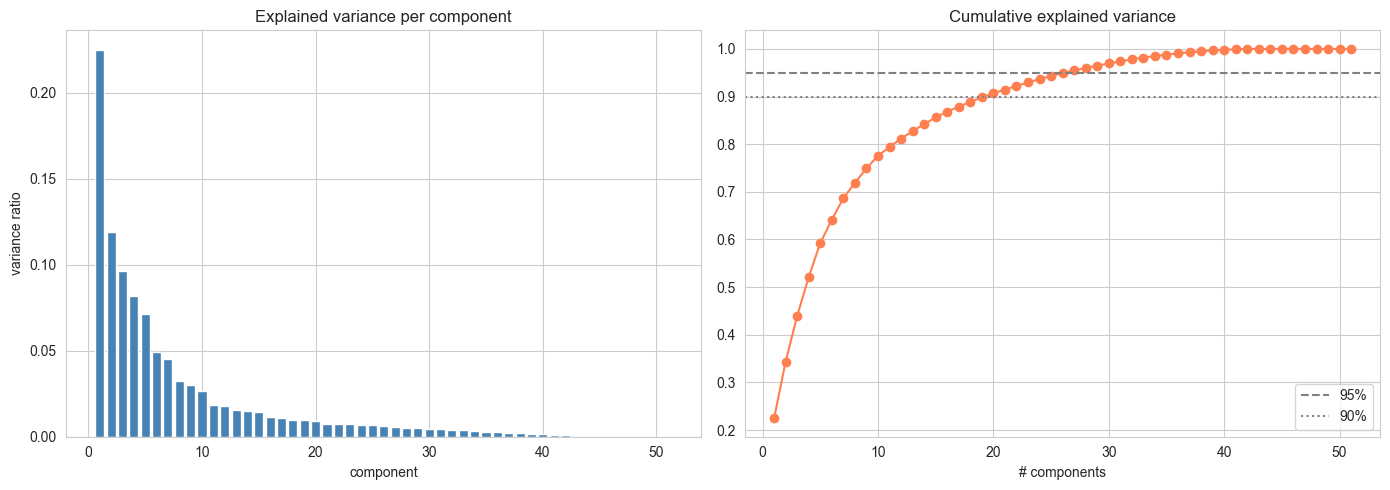

Components for 90% variance: 20 | for 95%: 27  (out of 51)
One-hot encoding spreads variance across many components -> PCA is mainly used here
for visualisation and to denoise the clustering space, not for hard dimensionality reduction.


In [18]:
pca = PCA(random_state=SEED).fit(X_train_proc)
explained = pca.explained_variance_ratio_
cum = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(explained)+1), explained, color='steelblue')
axes[0].set_title('Explained variance per component')
axes[0].set_xlabel('component'); axes[0].set_ylabel('variance ratio')
axes[1].plot(range(1, len(cum)+1), cum, marker='o', color='coral')
axes[1].axhline(0.95, ls='--', color='gray', label='95%')
axes[1].axhline(0.90, ls=':', color='gray', label='90%')
axes[1].set_title('Cumulative explained variance')
axes[1].set_xlabel('# components'); axes[1].legend()
plt.tight_layout(); plt.show()

n95 = int(np.argmax(cum >= 0.95) + 1)
n90 = int(np.argmax(cum >= 0.90) + 1)
print(f'Components for 90% variance: {n90} | for 95%: {n95}  (out of {len(explained)})')
print('One-hot encoding spreads variance across many components -> PCA is mainly used here\n'
      'for visualisation and to denoise the clustering space, not for hard dimensionality reduction.')

### I.2 PCA 2-D projection coloured by target

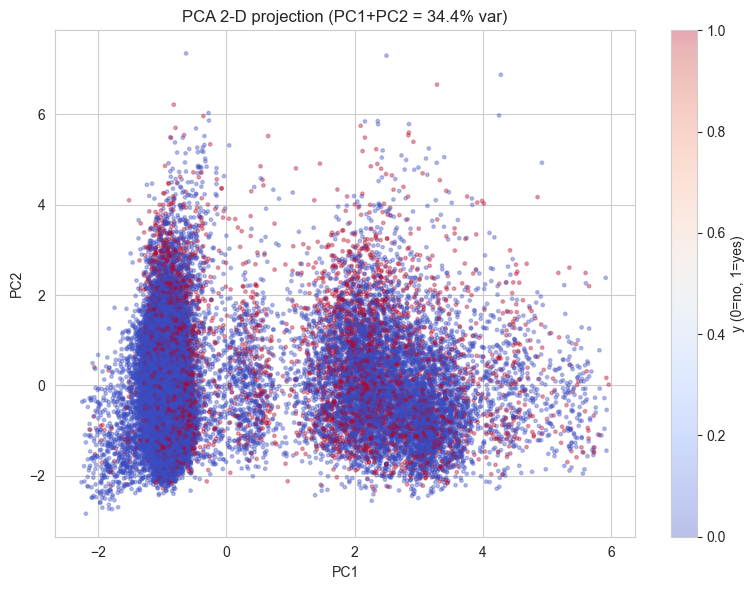

The positive class is not linearly separated in 2-D -> the problem is genuinely hard
and we should not expect clusters to map cleanly onto the target.


In [19]:
pca2 = PCA(n_components=2, random_state=SEED)
X2 = pca2.fit_transform(X_train_proc)
plt.figure(figsize=(8, 6))
sc = plt.scatter(X2[:, 0], X2[:, 1], c=y_train, cmap='coolwarm', alpha=0.35, s=6)
plt.colorbar(sc, label='y (0=no, 1=yes)')
plt.title(f'PCA 2-D projection (PC1+PC2 = {pca2.explained_variance_ratio_.sum():.1%} var)')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.tight_layout(); plt.show()
print('The positive class is not linearly separated in 2-D -> the problem is genuinely hard\n'
      'and we should not expect clusters to map cleanly onto the target.')

### I.3 K-Means — Elbow & Silhouette
Clustering is performed in the PCA space that retains 90% of the variance (denoised, faster).

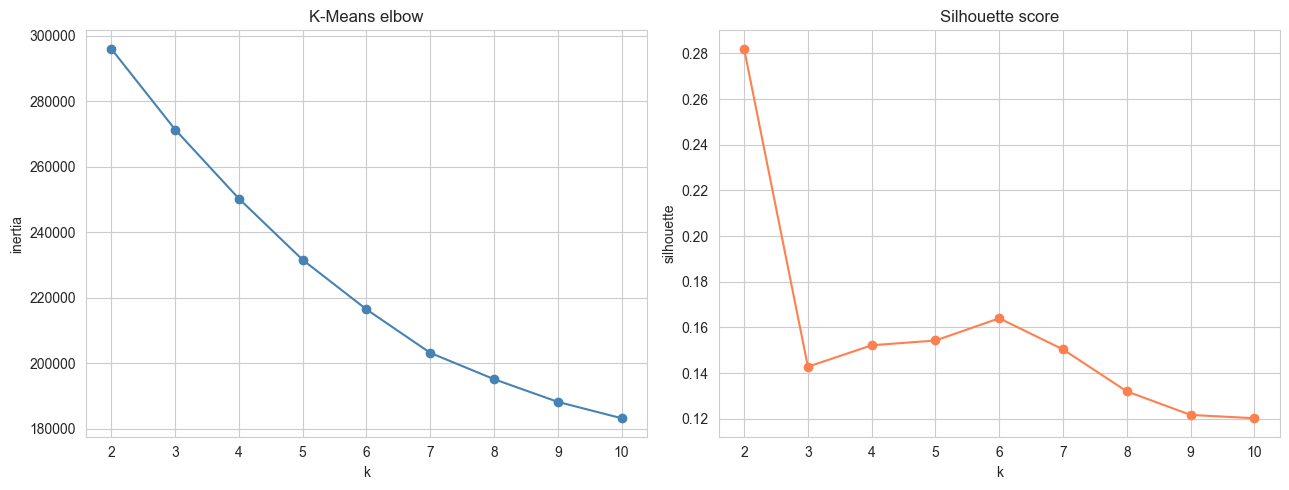

Best k by silhouette: 2 (silhouette = 0.282)


In [20]:
pca_clust = PCA(n_components=n90, random_state=SEED)
X_clust = pca_clust.fit_transform(X_train_proc)

k_range = range(2, K_MAX + 1)
inertias, sils = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X_clust)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_clust, km.labels_, sample_size=SIL_SAMPLE, random_state=SEED))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes[0].set_title('K-Means elbow'); axes[0].set_xlabel('k'); axes[0].set_ylabel('inertia')
axes[1].plot(list(k_range), sils, marker='o', color='coral')
axes[1].set_title('Silhouette score'); axes[1].set_xlabel('k'); axes[1].set_ylabel('silhouette')
plt.tight_layout(); plt.show()

best_k = list(k_range)[int(np.argmax(sils))]
print(f'Best k by silhouette: {best_k} (silhouette = {max(sils):.3f})')

### I.4 GMM — BIC & AIC

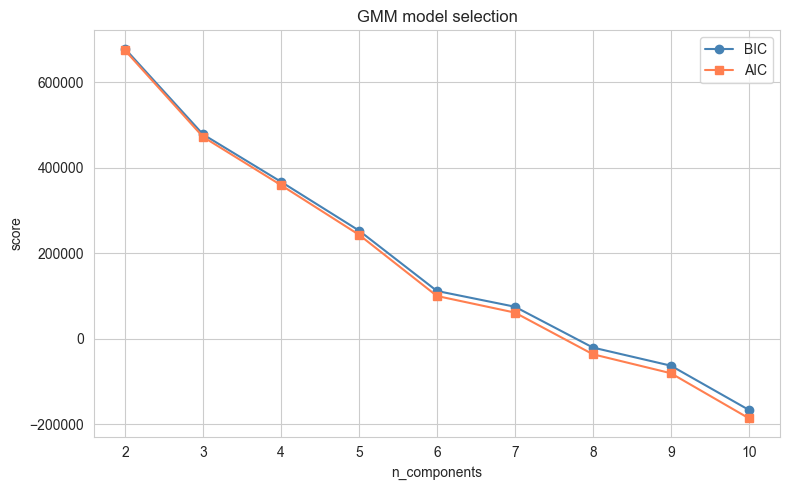

Best k by BIC: 10 | by AIC: 10


In [21]:
bics, aics = [], []
for k in k_range:
    g = GaussianMixture(n_components=k, random_state=SEED, n_init=2).fit(X_clust)
    bics.append(g.bic(X_clust)); aics.append(g.aic(X_clust))
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), bics, marker='o', label='BIC', color='steelblue')
plt.plot(list(k_range), aics, marker='s', label='AIC', color='coral')
plt.title('GMM model selection'); plt.xlabel('n_components'); plt.ylabel('score'); plt.legend()
plt.tight_layout(); plt.show()
print(f'Best k by BIC: {list(k_range)[int(np.argmin(bics))]} | by AIC: {list(k_range)[int(np.argmin(aics))]}')

### I.5 Do clusters align with the target?
We compare the K-Means partition to `y` two ways: per-cluster subscription rate, and the **Adjusted Rand Index** (ARI) between clusters and labels.

         subscription_rate      n
cluster                          
0                    0.254   8979
1                    0.150  27189

Adjusted Rand Index (clusters vs y): 0.064
ARI near 0 => the unsupervised structure is driven by demographics/contact patterns,
NOT by the rare subscription outcome. Useful as a sanity check, not as a classifier.


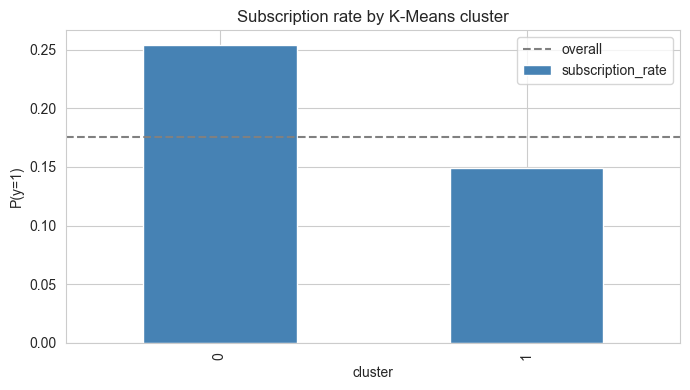

In [22]:
km_best = KMeans(n_clusters=best_k, random_state=SEED, n_init=10).fit(X_clust)
lab = km_best.labels_

al = pd.DataFrame({'cluster': lab, 'y': y_train.values})
rate = al.groupby('cluster')['y'].agg(['mean', 'size'])
rate.columns = ['subscription_rate', 'n']
print(rate.round(3).to_string())

ari = adjusted_rand_score(y_train, lab)
print(f'\nAdjusted Rand Index (clusters vs y): {ari:.3f}')
print('ARI near 0 => the unsupervised structure is driven by demographics/contact patterns,\n'
      'NOT by the rare subscription outcome. Useful as a sanity check, not as a classifier.')

ax = rate['subscription_rate'].plot(kind='bar', color='steelblue', figsize=(7,4),
                                    title='Subscription rate by K-Means cluster')
ax.axhline(y_train.mean(), ls='--', color='gray', label='overall'); ax.legend()
plt.ylabel('P(y=1)'); plt.tight_layout(); plt.show()

---
## Phase II — Linear and Regularised Models

### II.1 Baselines (mandatory)
Two trivial references: a **stratified** random guesser and a **majority-class** classifier. They frame every later score — note the majority baseline's deceptively high accuracy.

In [24]:
for strat in ['stratified', 'most_frequent']:
    d = DummyClassifier(strategy=strat, random_state=SEED).fit(X_train_proc, y_train)
    yp = d.predict(X_test_proc)
    acc = accuracy_score(y_test, yp); f1 = f1_score(y_test, yp, zero_division=0)
    print(f'Baseline [{strat:13s}] Accuracy {acc:.3f} | F1 {f1:.3f}')
print('\n=> Accuracy alone is meaningless on this imbalanced task; F1/AUPR are what matter.')

Baseline [stratified   ] Accuracy 0.714 | F1 0.171
Baseline [most_frequent] Accuracy 0.825 | F1 0.000

=> Accuracy alone is meaningless on this imbalanced task; F1/AUPR are what matter.


### II.2 Logistic Regression — effect of regularisation (C = 1/λ)
We sweep the inverse-regularisation strength `C` and record **train F1** and **5-fold CV F1** (never the test set) plus the L2 norm of the coefficients. The train–CV gap shows over-fitting; the coefficient norm shrinks as λ grows (smaller C).

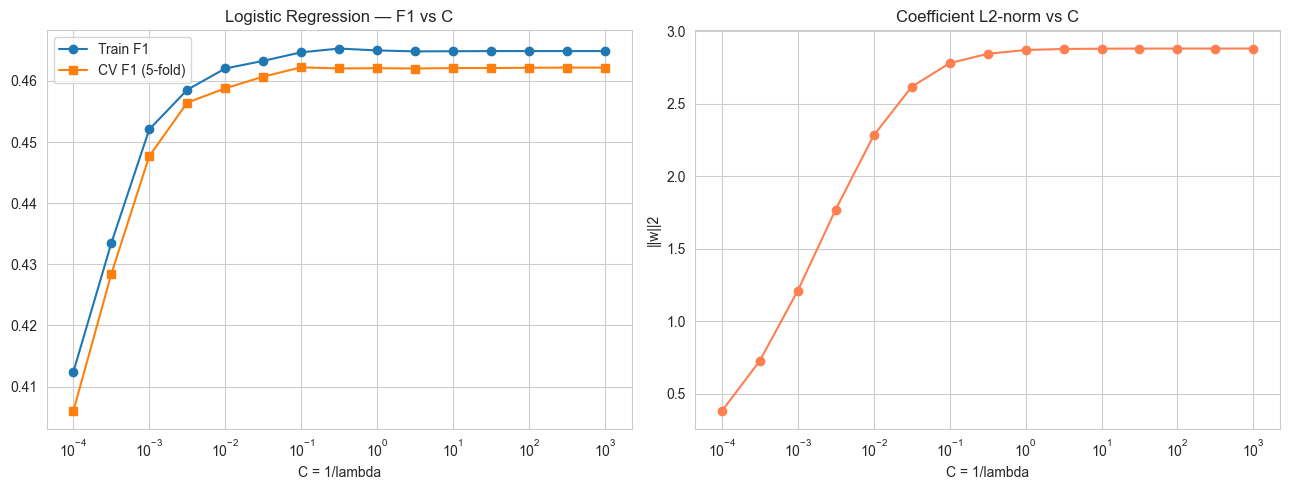

Best C by CV-F1: 0.1  (CV-F1 = 0.462)


In [25]:
C_values = np.logspace(-4, 3, CP_PATH_POINTS)
cv5 = StratifiedKFold(5, shuffle=True, random_state=SEED)
train_f1, cv_f1, coef_norm = [], [], []
for Cval in C_values:
    pipe = Pipeline([('prep', clone(preprocessor)),
                     ('clf', LogisticRegression(C=Cval, max_iter=2000,
                              class_weight='balanced', random_state=SEED))])
    s = cross_val_score(pipe, X_train, y_train, cv=cv5, scoring='f1', n_jobs=-1)
    cv_f1.append(s.mean())
    pipe.fit(X_train, y_train)
    train_f1.append(f1_score(y_train, pipe.predict(X_train)))
    coef_norm.append(np.linalg.norm(pipe.named_steps['clf'].coef_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].semilogx(C_values, train_f1, marker='o', label='Train F1')
axes[0].semilogx(C_values, cv_f1, marker='s', label='CV F1 (5-fold)')
axes[0].set_title('Logistic Regression — F1 vs C'); axes[0].set_xlabel('C = 1/lambda'); axes[0].legend()
axes[1].semilogx(C_values, coef_norm, marker='o', color='coral')
axes[1].set_title('Coefficient L2-norm vs C'); axes[1].set_xlabel('C = 1/lambda'); axes[1].set_ylabel('||w||2')
plt.tight_layout(); plt.show()

best_C = float(C_values[int(np.argmax(cv_f1))])
print(f'Best C by CV-F1: {best_C:.4g}  (CV-F1 = {max(cv_f1):.3f})')

### II.3 Ridge vs Lasso — coefficient shrinkage & L1 feature selection
For a classification target, Ridge/Lasso are the L2/L1 penalties of logistic regression. We trace the **Lasso path** (showing how L1 drives coefficients to exactly zero) and compare **L1 vs L2** logistic regression in CV performance and sparsity.


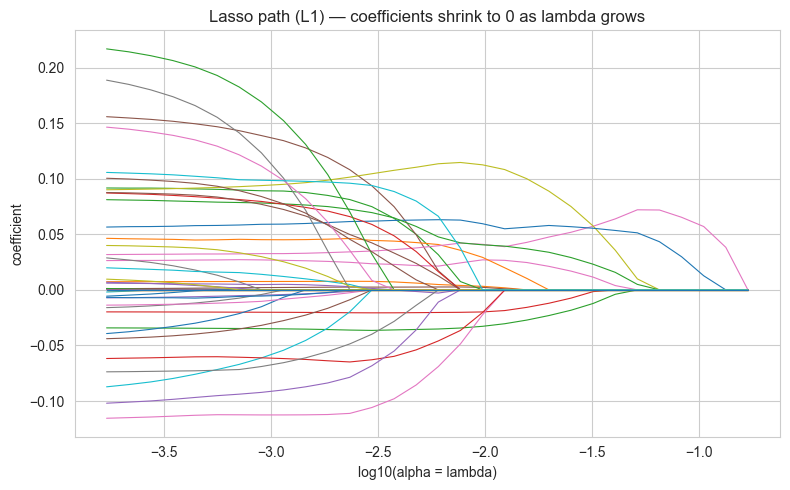

Non-zero coefficients along the Lasso path: [0, 4, 8, 21, 31, 38] ...
=> at the sparsest end only 0 of 51 features survive (feature selection).

L1 vs L2 penalised logistic regression (CV ROC-AUC & sparsity):
  Ridge-like (L2)  CV ROC-AUC 0.7755 | non-zero coefs 51/51
  Lasso-like (L1)  CV ROC-AUC 0.7754 | non-zero coefs 46/51


In [26]:
# (a) Lasso coefficient path (L1) on the standardised design matrix
alphas, coefs, _ = lasso_path(X_train_proc, y_train.values, n_alphas=30)
plt.figure(figsize=(8, 5))
for i in range(coefs.shape[0]):
    plt.plot(np.log10(alphas), coefs[i], lw=0.8)
plt.title('Lasso path (L1) — coefficients shrink to 0 as lambda grows')
plt.xlabel('log10(alpha = lambda)'); plt.ylabel('coefficient'); plt.tight_layout(); plt.show()

nz = (np.abs(coefs) > 1e-6).sum(axis=0)
print('Non-zero coefficients along the Lasso path:', list(nz[::5]), '...')
print(f'=> at the sparsest end only {nz.min()} of {coefs.shape[0]} features survive (feature selection).')

# (b) L1 vs L2 logistic regression (Lasso-like vs Ridge-like)
print('\nL1 vs L2 penalised logistic regression (CV ROC-AUC & sparsity):')
for pen, solver in [('l2', 'lbfgs'), ('l1', 'saga')]:
    pipe = Pipeline([('prep', clone(preprocessor)),
                     ('clf', LogisticRegression(penalty=pen, solver=solver, C=best_C,
                              max_iter=4000, class_weight='balanced', random_state=SEED))])
    auc = cross_val_score(pipe, X_train, y_train, cv=cv5, scoring='roc_auc', n_jobs=-1).mean()
    pipe.fit(X_train, y_train)
    nzero = int((np.abs(pipe.named_steps['clf'].coef_) > 1e-6).sum())
    total = pipe.named_steps['clf'].coef_.size
    name = 'Ridge-like (L2)' if pen == 'l2' else 'Lasso-like (L1)'
    print(f'  {name:16s} CV ROC-AUC {auc:.4f} | non-zero coefs {nzero}/{total}')

### II.4 Final logistic regression — test evaluation & coefficient interpretation

              precision    recall  f1-score   support

           0      0.916     0.724     0.809      7457
           1      0.347     0.689     0.461      1586

    accuracy                          0.718      9043
   macro avg      0.631     0.706     0.635      9043
weighted avg      0.816     0.718     0.748      9043

ROC-AUC 0.7794 | AUPR 0.4372


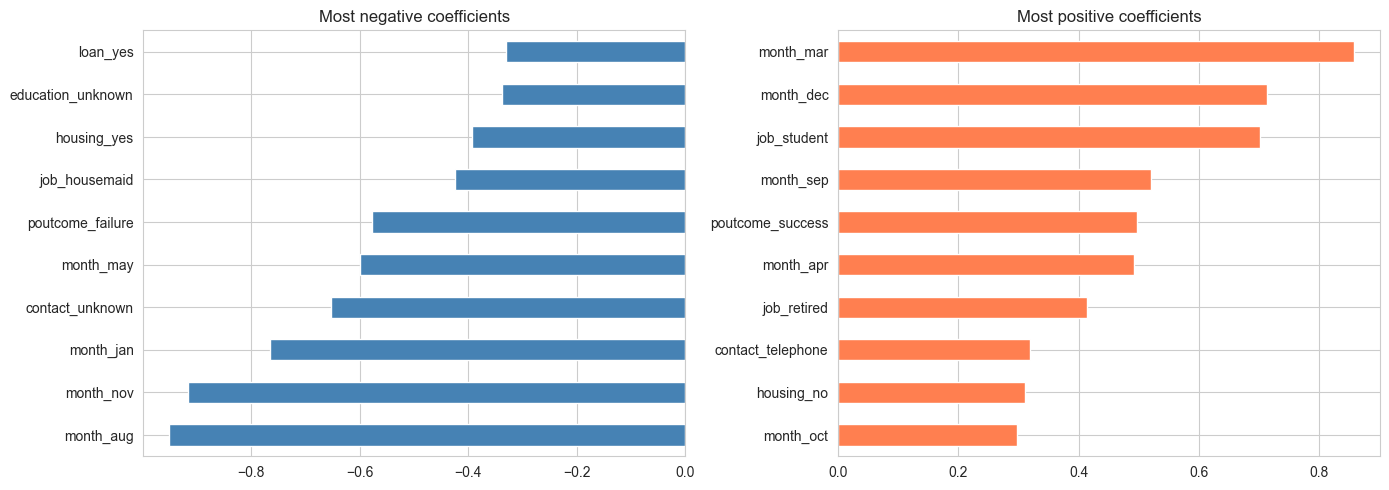

Positive drivers (e.g. poutcome=success, contacted by cellular, certain months) match the EDA.


In [27]:
logreg = Pipeline([('prep', clone(preprocessor)),
                   ('clf', LogisticRegression(C=best_C, max_iter=2000,
                            class_weight='balanced', random_state=SEED))]).fit(X_train, y_train)
proba = logreg.predict_proba(X_test)[:, 1]
print(classification_report(y_test, logreg.predict(X_test), digits=3))
print(f'ROC-AUC {roc_auc_score(y_test, proba):.4f} | AUPR {average_precision_score(y_test, proba):.4f}')

coef = pd.Series(logreg.named_steps['clf'].coef_.ravel(), index=feature_names).sort_values()
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
coef.head(10).plot(kind='barh', ax=ax[0], color='steelblue'); ax[0].set_title('Most negative coefficients')
coef.tail(10).plot(kind='barh', ax=ax[1], color='coral');     ax[1].set_title('Most positive coefficients')
plt.tight_layout(); plt.show()
print('Positive drivers (e.g. poutcome=success, contacted by cellular, certain months) match the EDA.')

---
## Phase III — Kernel Methods (SVM)

### III.1 Why a subsample
A kernel SVM is roughly O(n²–n³). On 36k training rows with `probability=True` it is impractical, so kernels are compared on a **stratified subsample**; the class ratio is preserved. SVM is studied as a kernel method here, not as the deployment candidate.

In [28]:
idx = resample(np.arange(len(X_train_proc)), n_samples=SVM_SUBSAMPLE,
               random_state=SEED, stratify=y_train)
X_svm, y_svm = X_train_proc[idx], y_train.iloc[idx].reset_index(drop=True)
print(f'SVM subset: {X_svm.shape} | positive rate {y_svm.mean():.3f}')

SVM subset: (8000, 51) | positive rate 0.175


### III.2 Linear vs Polynomial vs RBF kernel (CV on the subsample)
Selection uses 5-fold CV **AUPR on the subsample** — the test set is not touched here.

In [29]:
cv5 = StratifiedKFold(5, shuffle=True, random_state=SEED)
svm_rows = []
for kernel in ['linear', 'poly', 'rbf']:
    svm = SVC(kernel=kernel, class_weight='balanced', random_state=SEED)
    sc = cross_validate(svm, X_svm, y_svm, cv=cv5,
                        scoring=['average_precision', 'roc_auc', 'f1'], n_jobs=-1)
    svm_rows.append({'kernel': kernel,
                     'CV_AUPR': sc['test_average_precision'].mean(),
                     'CV_ROC_AUC': sc['test_roc_auc'].mean(),
                     'CV_F1': sc['test_f1'].mean()})
    print(f"{kernel.upper():7s} CV-AUPR {svm_rows[-1]['CV_AUPR']:.4f} | "
          f"ROC-AUC {svm_rows[-1]['CV_ROC_AUC']:.4f} | F1 {svm_rows[-1]['CV_F1']:.4f}")
svm_kernel_df = pd.DataFrame(svm_rows).set_index('kernel')
svm_kernel_df.round(4)

LINEAR  CV-AUPR 0.4349 | ROC-AUC 0.7707 | F1 0.4555
POLY    CV-AUPR 0.4337 | ROC-AUC 0.7629 | F1 0.4633
RBF     CV-AUPR 0.4346 | ROC-AUC 0.7750 | F1 0.4689


,CV_AUPR,CV_ROC_AUC,CV_F1
kernel,,,
linear,0.4349,0.7707,0.4555
poly,0.4337,0.7629,0.4633
rbf,0.4346,0.7750,0.4689


### III.3 RBF-SVM hyper-parameter tuning (Grid Search)

In [30]:
param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.1]}
gs_svm = GridSearchCV(SVC(kernel='rbf', class_weight='balanced', random_state=SEED),
                      param_grid, cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
                      scoring='average_precision', n_jobs=-1, verbose=1)
gs_svm.fit(X_svm, y_svm)
print(f'Best SVM params: {gs_svm.best_params_}')
print(f'Best CV AUPR:    {gs_svm.best_score_:.4f}')

# Final SVM fit (with probability for downstream curves) on the subsample
svm_best = SVC(kernel='rbf', probability=True, class_weight='balanced',
               random_state=SEED, **gs_svm.best_params_).fit(X_svm, y_svm)
sp = svm_best.predict_proba(X_test_proc)[:, 1]
print(f'Tuned RBF-SVM on TEST: ROC-AUC {roc_auc_score(y_test, sp):.4f} | '
      f'AUPR {average_precision_score(y_test, sp):.4f}')

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best SVM params: {'C': 1, 'gamma': 0.01}
Best CV AUPR:    0.4323
Tuned RBF-SVM on TEST: ROC-AUC 0.7780 | AUPR 0.4352


---
## Phase IV — Ensemble Methods

### IV.1–IV.3 Random Forest (bagging), Gradient Boosting & AdaBoost (boosting)
All three are fit on the **full** training set via pipelines; we record training time and test metrics. RF uses `class_weight='balanced'`; the boosting models have no such parameter, so their operating point is set later by threshold tuning (decision #4).

In [28]:
ensembles = {
    'Random Forest':     Pipeline([('prep', clone(preprocessor)),
                          ('clf', RandomForestClassifier(n_estimators=RF_N_EST, class_weight='balanced',
                                   random_state=SEED, n_jobs=-1))]),
    'Gradient Boosting': Pipeline([('prep', clone(preprocessor)),
                          ('clf', GradientBoostingClassifier(n_estimators=GB_N_EST, random_state=SEED))]),
    'AdaBoost':          Pipeline([('prep', clone(preprocessor)),
                          ('clf', AdaBoostClassifier(n_estimators=ADA_N_EST, random_state=SEED))]),
}
ens_rows = []
for name, pipe in ensembles.items():
    t0 = time.time(); pipe.fit(X_train, y_train); tt = time.time() - t0
    pr = pipe.predict_proba(X_test)[:, 1]; pd_ = pipe.predict(X_test)
    ens_rows.append({'Model': name, 'Train_time_s': round(tt, 1),
                     'F1': f1_score(y_test, pd_),
                     'ROC_AUC': roc_auc_score(y_test, pr),
                     'AUPR': average_precision_score(y_test, pr)})
    print(f'{name:18s} time {tt:5.1f}s | F1 {ens_rows[-1]["F1"]:.4f} | '
          f'ROC-AUC {ens_rows[-1]["ROC_AUC"]:.4f} | AUPR {ens_rows[-1]["AUPR"]:.4f}')
pd.DataFrame(ens_rows).set_index('Model').round(4)

Random Forest      time  13.0s | F1 0.2660 | ROC-AUC 0.7614 | AUPR 0.4233


Gradient Boosting  time  11.9s | F1 0.3010 | ROC-AUC 0.7892 | AUPR 0.4596


AdaBoost           time   5.8s | F1 0.2869 | ROC-AUC 0.7861 | AUPR 0.4580


,Train_time_s,F1,ROC_AUC,AUPR
Model,,,,
Random Forest,13.0,0.2660,0.7614,0.4233
Gradient Boosting,11.9,0.3010,0.7892,0.4596
AdaBoost,5.8,0.2869,0.7861,0.4580


### IV.4 Feature importance & training-time comparison
Impurity-based importance can be biased toward high-cardinality features, so for the Random Forest we also report **permutation importance** on the test set (model-agnostic, AUPR-scored) and check the two rankings agree.

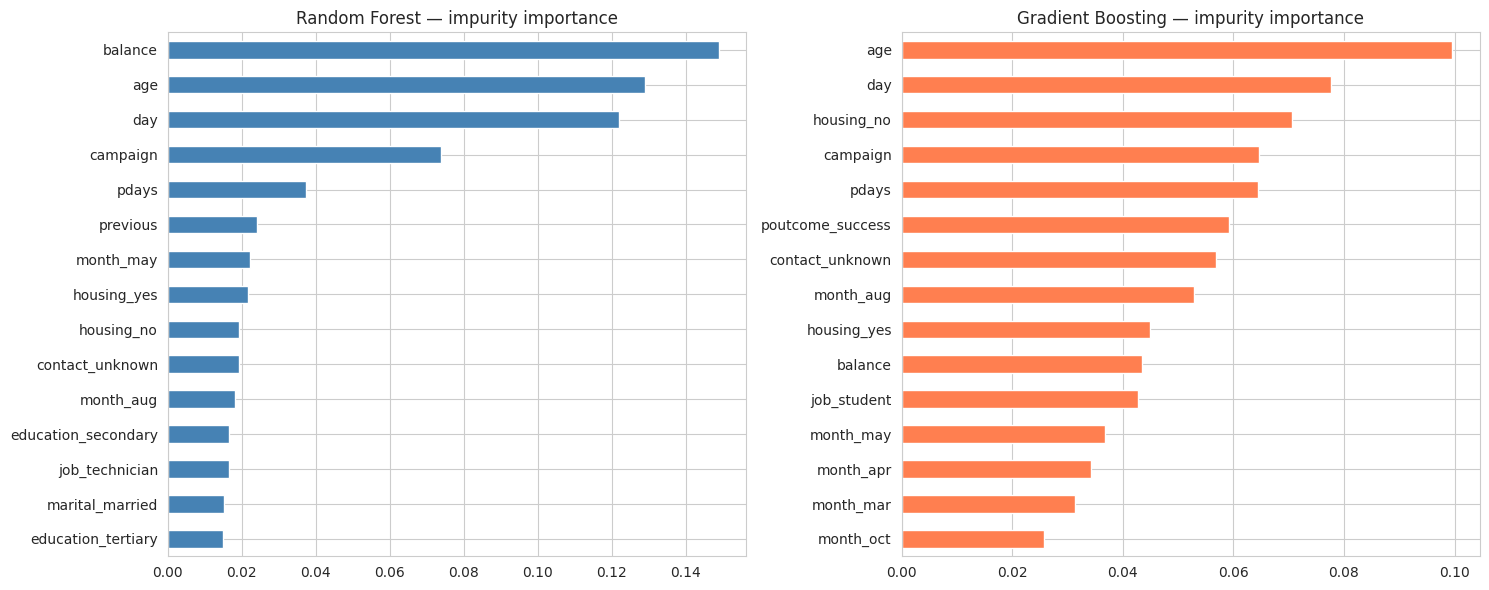

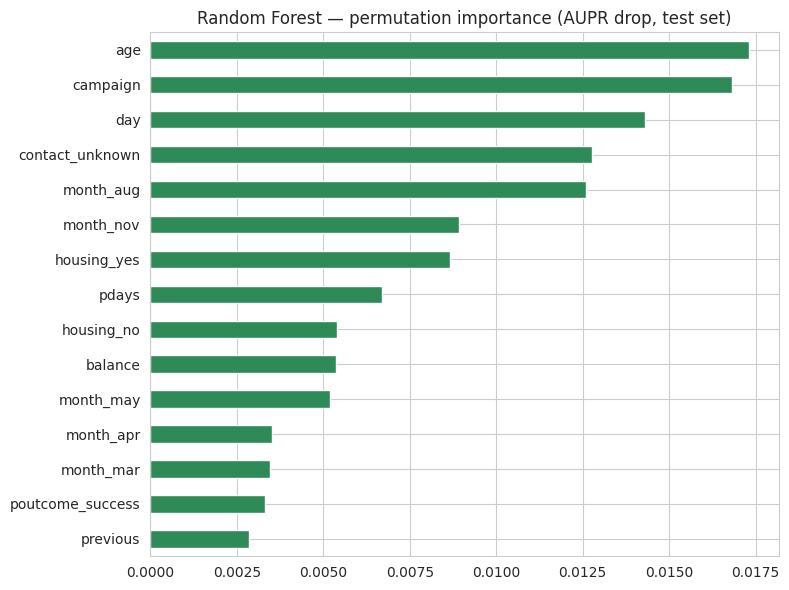

Top permutation features: ['age', 'campaign', 'day', 'contact_unknown', 'month_aug', 'month_nov']


In [29]:
rf_pipe = ensembles['Random Forest']; gb_pipe = ensembles['Gradient Boosting']

def top_imp(pipe, k=15):
    imp = pd.Series(pipe.named_steps['clf'].feature_importances_, index=feature_names)
    return imp.nlargest(k).sort_values()

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
top_imp(rf_pipe).plot(kind='barh', ax=ax[0], color='steelblue'); ax[0].set_title('Random Forest — impurity importance')
top_imp(gb_pipe).plot(kind='barh', ax=ax[1], color='coral');     ax[1].set_title('Gradient Boosting — impurity importance')
plt.tight_layout(); plt.show()

# Permutation importance on the TRANSFORMED test matrix (the fitted classifier alone),
# so the 51 columns line up 1:1 with `feature_names` and are directly comparable to impurity.
X_test_t = rf_pipe.named_steps['prep'].transform(X_test)
perm = permutation_importance(rf_pipe.named_steps['clf'], X_test_t, y_test, scoring='average_precision',
                              n_repeats=PERM_REPEATS, random_state=SEED, n_jobs=-1)
perm_s = pd.Series(perm.importances_mean, index=feature_names).nlargest(15).sort_values()
perm_s.plot(kind='barh', figsize=(8, 6), color='seagreen',
            title='Random Forest — permutation importance (AUPR drop, test set)')
plt.tight_layout(); plt.show()
print('Top permutation features:', list(perm_s.index[::-1][:6]))

---
## Phase V — Model Selection & Validation

### V.1 Hyper-parameter tuning by cross-validation (training set only)
Each scalable model is tuned with `GridSearchCV` (inner CV, AUPR-scored) on the training data; SVM is tuned on its subsample (Phase III). This fixes the classic mistake of selecting hyper-parameters on the test set.

In [30]:
inner = StratifiedKFold(INNER_SPLITS, shuffle=True, random_state=SEED)

search_spaces = {
  'Logistic Regression': (LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED),
                          {'clf__C': [0.01, 0.1, 1, 10]}),
  'Random Forest':       (RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1),
                          {'clf__n_estimators': [RF_N_EST], 'clf__max_depth': [None, 15]}),
  'Gradient Boosting':   (GradientBoostingClassifier(random_state=SEED),
                          {'clf__n_estimators': [GB_N_EST], 'clf__learning_rate': [0.05, 0.1]}),
  'AdaBoost':            (AdaBoostClassifier(random_state=SEED),
                          {'clf__n_estimators': [ADA_N_EST], 'clf__learning_rate': [0.5, 1.0]}),
}
tuned = {}
best_params = {}
for name, (est, grid) in search_spaces.items():
    pipe = Pipeline([('prep', clone(preprocessor)), ('clf', est)])
    gs = GridSearchCV(pipe, grid, cv=inner, scoring='average_precision', n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned[name] = gs.best_estimator_
    best_params[name] = gs.best_params_
    print(f'{name:20s} CV-AUPR {gs.best_score_:.4f} | {gs.best_params_}')
tuned['SVM (RBF)'] = svm_best  # tuned on subsample in Phase III
best_params['SVM (RBF)'] = gs_svm.best_params_

Logistic Regression  CV-AUPR 0.4490 | {'clf__C': 10}


Random Forest        CV-AUPR 0.4338 | {'clf__max_depth': 15, 'clf__n_estimators': 300}


Gradient Boosting    CV-AUPR 0.4667 | {'clf__learning_rate': 0.1, 'clf__n_estimators': 200}


AdaBoost             CV-AUPR 0.4631 | {'clf__learning_rate': 1.0, 'clf__n_estimators': 200}


### V.2 Nested cross-validation — unbiased model comparison
Outer 5-fold loop estimates generalisation; an inner `GridSearchCV` re-tunes inside every outer fold, so no information leaks from selection into evaluation. SVM is omitted (full-data nested CV is computationally infeasible for a kernel SVM). Scores are reported as mean ± std over the outer folds.

Logistic Regression  nested AUPR 0.4503 +/- 0.0152  [10s]


Random Forest        nested AUPR 0.4378 +/- 0.0112  [140s]


Gradient Boosting    nested AUPR 0.4660 +/- 0.0128  [117s]


AdaBoost             nested AUPR 0.4642 +/- 0.0145  [119s]


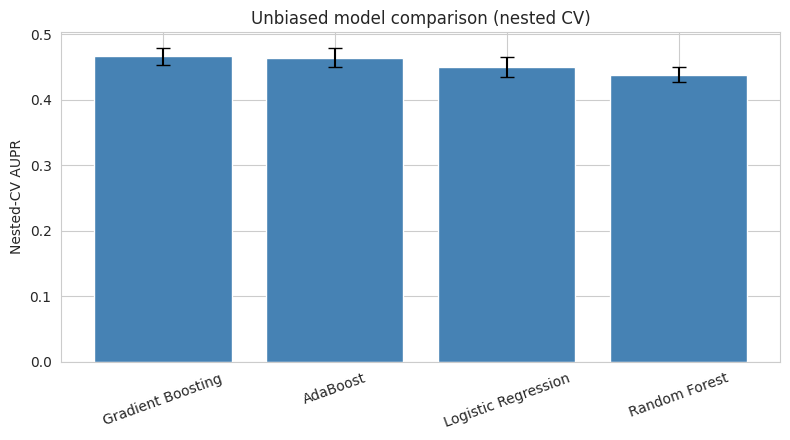

Best model by nested-CV AUPR: Gradient Boosting


In [31]:
outer = StratifiedKFold(OUTER_SPLITS, shuffle=True, random_state=SEED)
nested_spaces = {
  'Logistic Regression': (LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED),
                          {'clf__C': [0.01, 0.1, 1, 10]}),
  'Random Forest':       (RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1),
                          {'clf__n_estimators': [RF_N_EST_NESTED], 'clf__max_depth': [None, 15]}),
  'Gradient Boosting':   (GradientBoostingClassifier(random_state=SEED),
                          {'clf__n_estimators': [GB_N_EST_NESTED], 'clf__learning_rate': [0.05, 0.1]}),
  'AdaBoost':            (AdaBoostClassifier(random_state=SEED),
                          {'clf__n_estimators': [ADA_N_EST], 'clf__learning_rate': [0.5, 1.0]}),
}
nested_scores = {}
for name, (est, grid) in nested_spaces.items():
    pipe = Pipeline([('prep', clone(preprocessor)), ('clf', est)])
    clf = GridSearchCV(pipe, grid, cv=inner, scoring='average_precision', n_jobs=-1)
    t0 = time.time()
    s = cross_val_score(clf, X_train, y_train, cv=outer, scoring='average_precision', n_jobs=-1)
    nested_scores[name] = s
    print(f'{name:20s} nested AUPR {s.mean():.4f} +/- {s.std():.4f}  [{time.time()-t0:.0f}s]')

order = sorted(nested_scores, key=lambda k: -nested_scores[k].mean())
means = [nested_scores[k].mean() for k in order]
stds  = [nested_scores[k].std()  for k in order]
plt.figure(figsize=(8, 4.5))
plt.bar(order, means, yerr=stds, capsize=5, color='steelblue')
plt.ylabel('Nested-CV AUPR'); plt.title('Unbiased model comparison (nested CV)')
plt.xticks(rotation=20); plt.tight_layout(); plt.show()
best_model_name = order[0]
print(f'Best model by nested-CV AUPR: {best_model_name}')

### V.3 Decision-threshold tuning for the selected model
With imbalance, the default 0.5 threshold is rarely F1-optimal. Using **out-of-fold** probabilities on the training set (`cross_val_predict`, no leakage) we pick the threshold that maximises F1, then apply it unchanged to the test set.

F1-optimal threshold (from OOF train probs): 0.243 (default would be 0.5)


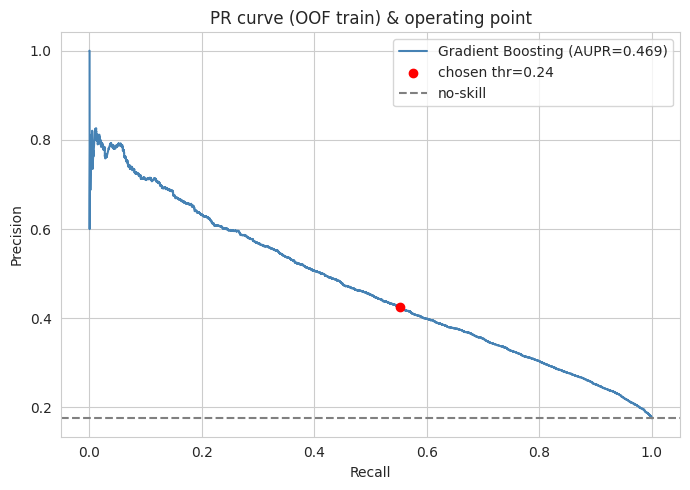

In [32]:
best_pipe = tuned[best_model_name]
oof = cross_val_predict(best_pipe, X_train, y_train, cv=cv5,
                        method='predict_proba', n_jobs=-1)[:, 1]
prec, rec, thr = precision_recall_curve(y_train, oof)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
best_thr = float(thr[int(np.argmax(f1s[:-1]))])
print(f'F1-optimal threshold (from OOF train probs): {best_thr:.3f} '
      f'(default would be 0.5)')

plt.figure(figsize=(7, 5))
plt.plot(rec, prec, color='steelblue', label=f'{best_model_name} (AUPR={average_precision_score(y_train, oof):.3f})')
plt.scatter(rec[np.argmax(f1s[:-1])], prec[np.argmax(f1s[:-1])], color='red', zorder=5,
            label=f'chosen thr={best_thr:.2f}')
plt.axhline(y_train.mean(), ls='--', color='gray', label='no-skill')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('PR curve (OOF train) & operating point')
plt.legend(); plt.tight_layout(); plt.show()

### V.4 Final evaluation on the held-out test set
All tuned models at the default threshold, plus the selected model at its tuned threshold. Ranked by AUPR.

In [33]:
rows = []
for name, pipe in tuned.items():
    Xte_eval = X_test_proc if name == 'SVM (RBF)' else X_test
    pr = pipe.predict_proba(Xte_eval)[:, 1]; pd_ = (pr >= 0.5).astype(int)
    rows.append({'Model': name,
                 'Accuracy': accuracy_score(y_test, pd_),
                 'Bal_Acc': balanced_accuracy_score(y_test, pd_),
                 'F1': f1_score(y_test, pd_),
                 'ROC_AUC': roc_auc_score(y_test, pr),
                 'AUPR': average_precision_score(y_test, pr)})

# selected model at tuned threshold
pr_best = best_pipe.predict_proba(X_test)[:, 1]; pd_best = (pr_best >= best_thr).astype(int)
rows.append({'Model': f'{best_model_name} @thr={best_thr:.2f}',
             'Accuracy': accuracy_score(y_test, pd_best),
             'Bal_Acc': balanced_accuracy_score(y_test, pd_best),
             'F1': f1_score(y_test, pd_best),
             'ROC_AUC': roc_auc_score(y_test, pr_best),
             'AUPR': average_precision_score(y_test, pr_best)})

results_df = pd.DataFrame(rows).set_index('Model').sort_values('AUPR', ascending=False)
display(results_df.round(4).style.background_gradient(cmap='Greens', subset=['F1','ROC_AUC','AUPR']))
results_df.round(4)

,Accuracy,Bal_Acc,F1,ROC_AUC,AUPR
Model,,,,,
Gradient Boosting @thr=0.24,0.787000,0.699600,0.482000,0.789200,0.459600
Gradient Boosting,0.833600,0.585900,0.301000,0.789200,0.459600
AdaBoost,0.835100,0.580800,0.286900,0.786100,0.458000
Random Forest,0.787600,0.689500,0.470700,0.777100,0.442800
Logistic Regression,0.717400,0.705000,0.459800,0.779300,0.437600
SVM (RBF),0.833100,0.581900,0.290600,0.778000,0.435200


,Accuracy,Bal_Acc,F1,ROC_AUC,AUPR
Model,,,,,
Gradient Boosting @thr=0.24,0.7870,0.6996,0.4820,0.7892,0.4596
Gradient Boosting,0.8336,0.5859,0.3010,0.7892,0.4596
AdaBoost,0.8351,0.5808,0.2869,0.7861,0.4580
Random Forest,0.7876,0.6895,0.4707,0.7771,0.4428
Logistic Regression,0.7174,0.7050,0.4598,0.7793,0.4376
SVM (RBF),0.8331,0.5819,0.2906,0.7780,0.4352


### V.5 ROC & Precision–Recall curves

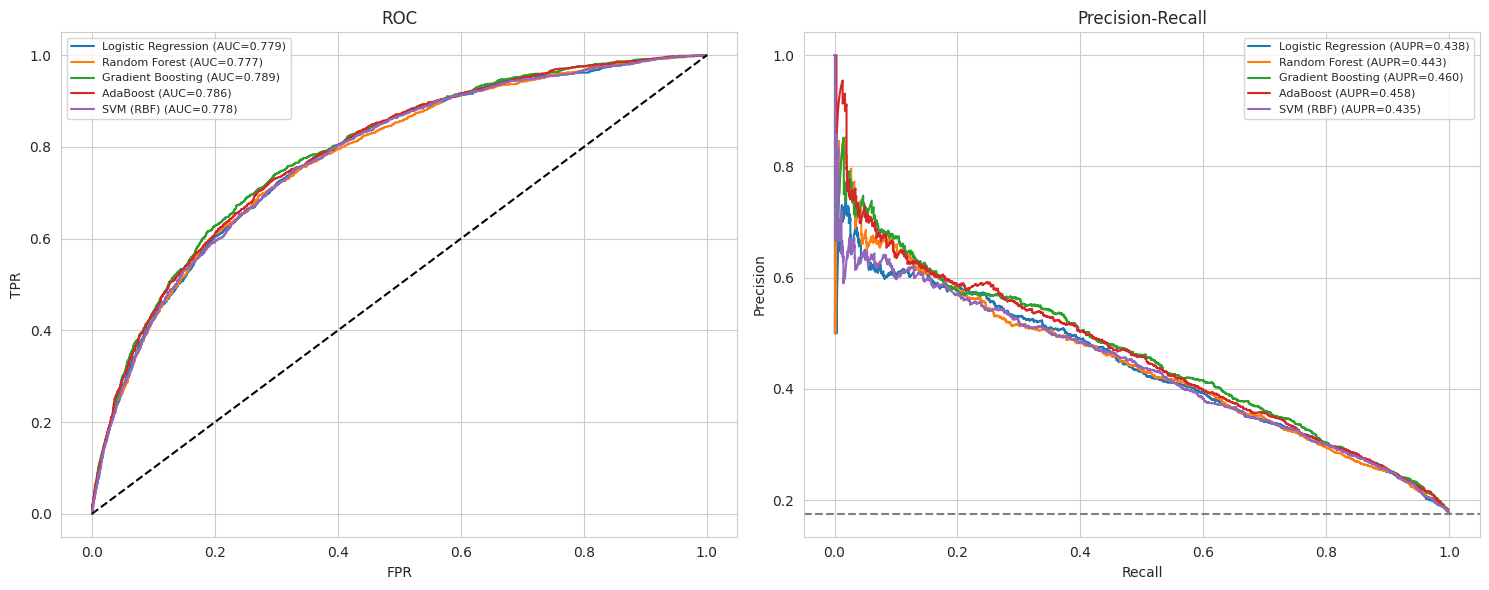

In [34]:
curve_models = {k: tuned[k] for k in ['Logistic Regression', 'Random Forest',
                                      'Gradient Boosting', 'AdaBoost', 'SVM (RBF)']}
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for name, pipe in curve_models.items():
    Xte_eval = X_test_proc if name == 'SVM (RBF)' else X_test
    pr = pipe.predict_proba(Xte_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, pr)
    p, r, _ = precision_recall_curve(y_test, pr)
    ax[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, pr):.3f})')
    ax[1].plot(r, p, label=f'{name} (AUPR={average_precision_score(y_test, pr):.3f})')
ax[0].plot([0, 1], [0, 1], 'k--'); ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR'); ax[0].set_title('ROC'); ax[0].legend(fontsize=8)
ax[1].axhline(y_test.mean(), ls='--', color='gray'); ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### V.6 Confusion matrices — default 0.5 vs tuned threshold
Shows concretely what the threshold buys: many more true positives recovered at the cost of some precision — the right trade-off if the goal is to find likely subscribers to call.

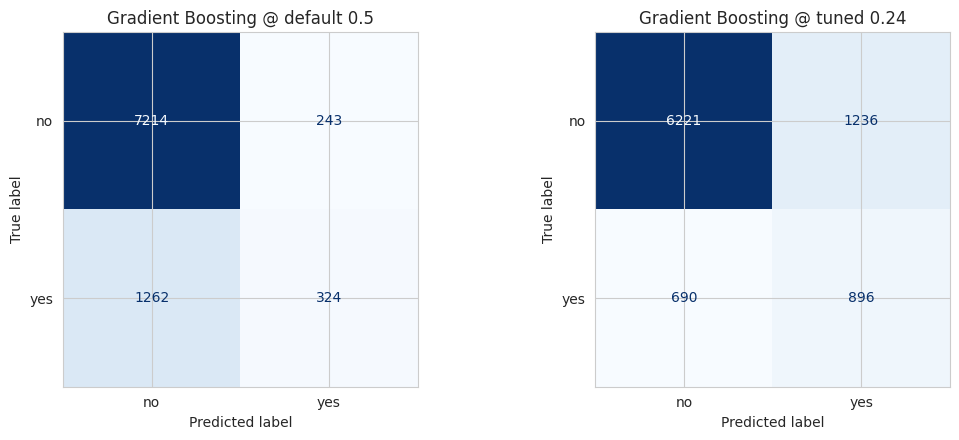

              precision    recall  f1-score   support

           0      0.900     0.834     0.866      7457
           1      0.420     0.565     0.482      1586

    accuracy                          0.787      9043
   macro avg      0.660     0.700     0.674      9043
weighted avg      0.816     0.787     0.799      9043



In [35]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for a, (thr, ttl) in zip(ax, [(0.5, 'default 0.5'), (best_thr, f'tuned {best_thr:.2f}')]):
    pd_ = (pr_best >= thr).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_test, pd_), display_labels=['no', 'yes']).plot(
        ax=a, colorbar=False, cmap='Blues')
    a.set_title(f'{best_model_name} @ {ttl}')
plt.tight_layout(); plt.show()
print(classification_report(y_test, (pr_best >= best_thr).astype(int), digits=3))

### V.7 Statistical significance of the model comparison
Paired tests on the per-fold nested-CV AUPR of the two best models. We report both a paired t-test and the non-parametric Wilcoxon signed-rank test; with only 5 folds these are indicative, and the folds are not fully independent (a known caveat of CV-based testing).

In [36]:
a, b = order[0], order[1]
sa, sb = nested_scores[a], nested_scores[b]
t_stat, t_p = ttest_rel(sa, sb)
try:
    w_stat, w_p = wilcoxon(sa, sb)
except ValueError:
    w_stat, w_p = np.nan, np.nan
print(f'Comparing {a} vs {b} (nested-CV AUPR over {OUTER_SPLITS} folds)')
print(f'  mean AUPR: {sa.mean():.4f} vs {sb.mean():.4f}')
print(f'  paired t-test:  t={t_stat:.3f}, p={t_p:.4f}')
print(f'  Wilcoxon:       W={w_stat}, p={w_p}')
print(f'  significant at 0.05: {bool(t_p < 0.05)}')

Comparing Gradient Boosting vs AdaBoost (nested-CV AUPR over 5 folds)
  mean AUPR: 0.4660 vs 0.4642
  paired t-test:  t=1.017, p=0.3665
  Wilcoxon:       W=3.0, p=0.3125
  significant at 0.05: False


---
## 6. Conclusions (auto-summary)
The cell below assembles the key numbers used throughout the analysis.


In [37]:
print('================ PROJECT SUMMARY ================')
print(f'Dataset: {df.shape[0]} samples, {X.shape[1]} predictive features '
      f'(duration dropped: {DROP_DURATION}), positive rate {y.mean():.3f}')
print(f'PCA: {n90} comps for 90% variance, {n95} for 95% (of {len(explained)}).')
print(f'Clustering: best k={best_k} (silhouette); ARI vs target = {ari:.3f} '
      f'-> clusters do NOT track the outcome.')
print(f'Logistic regularisation: best C={best_C:.4g}.')
best_row = results_df.drop(index=[i for i in results_df.index if "@thr" in i]).iloc[0]
print(f'Best model (test AUPR): {best_row.name} | '
      f'AUPR {best_row.AUPR:.3f} | ROC-AUC {best_row.ROC_AUC:.3f} | F1 {best_row.F1:.3f}')
print(f'Threshold tuning lifted F1 from default to '
      f'{results_df.loc[[i for i in results_df.index if "@thr" in i][0], "F1"]:.3f} '
      f'at threshold {best_thr:.2f}.')
print('================================================')

================ PROJECT SUMMARY ================
Dataset: 45211 samples, 16 predictive features (duration dropped: True), positive rate 0.175
PCA: 20 comps for 90% variance, 27 for 95% (of 51).
Clustering: best k=2 (silhouette); ARI vs target = 0.064 -> clusters do NOT track the outcome.
Logistic regularisation: best C=0.1.
Best model (test AUPR): Gradient Boosting | AUPR 0.460 | ROC-AUC 0.789 | F1 0.301
Threshold tuning lifted F1 from default to 0.482 at threshold 0.24.


### Reproducibility
Fixed `SEED = 42` throughout. Run top-to-bottom on Python 3.10+ with `numpy, pandas, scikit-learn, scipy, matplotlib, seaborn`. Runtime is dominated by the Phase V nested CV (a few minutes). All randomness (splits, K-Means `n_init`, subsampling, CV shuffling) is seeded.
